# Figure 1B — NDMM Swimmer Plot
Swimmer plot showing visit timeline, treatment response, RISS stage, and IMWG HRMM status for VRd cohort.

In [1]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(patchwork)
  library(dplyr)
  library(tidyr)
  library(forcats)
  library(scales)
  library(RColorBrewer)
  library(readr)
  library(svglite)
})

## Constants

In [2]:
# ── Patient groups ──
g1 <- c("FH1019", "FH1020", "FH1022", "FH1023",
        "FH1024", "FH1026", "FH1027", "FH1028")

g2 <- c("FH1001", "FH1002", "FH1003", "FH1004", "FH1005", "FH1006",
        "FH1007", "FH1008", "FH1009", "FH1010", "FH1011", "FH1012",
        "FH1014", "FH1015", "FH1016", "FH1017", "FH1018", "FH1021")

g1_order <- rev(g1)
g2_order <- rev(g2)

# ── Visit color palette ──
tp_color_map <- c(
  "MM Pre-Treatment"           = "#8B0000",
  "MM Post Induction 2-Cycles" = "#C20272",
  "MM End Induction 1st Draw"  = "#7502C2",
  "MM End Induction 2nd Draw"  = "#1f77b4",
  "MM Post Transplant 60 Days" = "#0021B0",
  "MM Post Transplant 90 Days" = "#2346DE",
  "MM Post Transplant 1 year"  = "#038AFF",
  "MM Post Transplant 2 year"  = "#008080"
)

shorthand <- c(
  "MM Pre-Treatment"           = "PreTx",
  "MM Post Induction 2-Cycles" = "PI2C",
  "MM End Induction 1st Draw"  = "EI",
  "MM End Induction 2nd Draw"  = "EI 2nd Draw",
  "MM Post Transplant 60 Days" = "ASCT60d",
  "MM Post Transplant 90 Days" = "ASCT90d",
  "MM Post Transplant 1 year"  = "ASCT1y",
  "MM Post Transplant 2 year"  = "ASCT2y"
)

# ── Response shapes ──
response_shapes <- c(
  "Partial Response (PR)"             = 10,
  "Very Good Partial Response (VGPR)" = 17,
  "Complete Response (CR)"            = 15,
  "Stringent Complete Response (sCR)" = 18
)
response_shapes_full <- c(response_shapes, "Missing" = 20)

# ── Risk factor colors ──
riss_colors <- c("I" = "#bdcabb", "II" = "#9ad091", "III" = "#2a7a4c")
hrmm_colors <- c("Yes" = "#003366", "No" = "#99CCFF")

## Theme & Save Helper

In [3]:
theme_ndmm <- function(base_size = 13) {
  theme_minimal(base_size = base_size) +
    theme(
      axis.text.y        = element_text(size = 9),
      legend.position.inside = c(1.05, 1),
      legend.justification = c("left", "top"),
      legend.background  = element_rect(fill = alpha("white", 0.8), color = NA),
      plot.title         = element_text(hjust = 0.5, face = "bold"),
      panel.border       = element_rect(colour = "black", fill = NA, linewidth = 1),
      panel.grid.major.y = element_blank(),
      panel.grid.minor.y = element_blank(),
      plot.margin        = margin(10, 160, 10, 10)
    )
}

save_plot <- function(filename, plot, width = 12, height = 2.21, ...) {
  folder <- "../../data/figure-outputs/supplementary-3"
  dir.create(folder, showWarnings = FALSE, recursive = TRUE)
  base <- tools::file_path_sans_ext(basename(filename))
  for (fmt in c("pdf", "svg")) {
    path <- file.path(folder, paste0(base, ".", fmt))
    ggsave(path, plot = plot, width = width, height = height,
           device = fmt, units = "in", ...)
    message("Saved ", toupper(fmt), ": ", path)
  }
}

## Load & Prepare Metadata

In [4]:
prepare_meta_data <- function(file_path) {
  # Response columns to pivot into long format
  # NOTE: "Investigator assessed response category..." replaces the old
  #       "tb.end_induction_response" column from earlier CSV versions.
  response_columns <- c(
    "Investigator assessed response category (based on available data)",
    "tb.post_trans_90d_response",
    "tb.PostTX_1Yr_response",
    "tb.PostTX_2Yr_response"
  )

  # Load & initial filtering
  meta <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE) %>%
    filter(Subject != "",
           visitDetails != "MM End Induction 2nd Draw")

  # Treatment group assignment
  meta$treatment_group <- ifelse(meta$Subject %in% g1, "Dara", "VRd")

  # Drop post-transplant visits for Dara patients
  post_tx <- c("MM Post Transplant 60 Days", "MM Post Transplant 90 Days",
               "MM Post Transplant 1 year",  "MM Post Transplant 2 year")
  meta <- meta %>%
    filter(!(treatment_group == "Dara" & visitDetails %in% post_tx))

  # Coerce key numeric columns
  num_cols <- c("ageAtEnrollment", "daysSinceFirstVisit")
  meta[num_cols] <- lapply(meta[num_cols], function(x) as.numeric(as.character(x)))

  # Clean visits & deduplicate
  meta <- meta %>%
    filter(!is.na(visitDetails),
           !grepl("N/A|Other", visitDetails, ignore.case = TRUE)) %>%
    arrange(Subject, daysSinceFirstVisit) %>%
    distinct(Subject, daysSinceFirstVisit, .keep_all = TRUE)

  # Factor ordering
  meta$Subject       <- factor(meta$Subject, levels = unique(meta$Subject))
  meta$visitDetails  <- factor(meta$visitDetails, levels = unique(meta$visitDetails))
  meta$SubjectPosition <- match(meta$Subject, unique(meta$Subject))

  # Simplify immunofixation (column is now "Immunofixation")
  if ("Immunofixation" %in% names(meta)) {
    meta$Immunofixation <- as.character(meta$Immunofixation)
    meta$immunofixation_clean <- ifelse(
      is.na(meta$Immunofixation) |
        trimws(meta$Immunofixation) %in% c("NA", "nan", "", NA),
      "Unknown", "Abnormal"
    )
    meta$immunofixation_clean <- factor(
      meta$immunofixation_clean, levels = c("Abnormal", "Unknown")
    )
  }

  # Coalesce response columns into a single Response column
  # Each row has at most one non-NA value across response columns,
  # so coalesce picks the correct one without needing pivot + distinct.
  response_columns <- response_columns[response_columns %in% names(meta)]

  # Replace empty strings / "NA" text with real NA before coalescing
  for (col in response_columns) {
    meta[[col]] <- ifelse(
      trimws(meta[[col]]) %in% c("", "NA", "nan"), NA_character_, meta[[col]]
    )
  }

  meta$Response <- do.call(coalesce, meta[response_columns])
  meta
}

meta_combo <- prepare_meta_data("../../data/figure-inputs/metadata/sup_table1.csv")

## Assign Groups & Build Plotting Data

In [5]:
# Filter to VRd patients only
meta_long <- meta_combo %>%
  filter(Subject %in% g1) %>%
  mutate(
    Subject = factor(Subject, levels = g1_order),
    SubjectPosition = Subject
  )

visit_order <- unique(meta_long$visitDetails)
meta_long$visitDetails <- factor(meta_long$visitDetails, levels = visit_order)
meta_long$Response     <- factor(meta_long$Response,
                                 levels = names(response_shapes), ordered = TRUE)

meta_long <- meta_long %>%
  mutate(
    ResponsePresent = !is.na(Response),
    point_shape     = ifelse(ResponsePresent, as.character(Response), "Missing"),
    fill_color      = visitDetails,
    point_color     = ifelse(ResponsePresent, "black", as.character(visitDetails))
  )

## Swimmer Plot (Treatment Response Over Time)

In [6]:
# Remove PD from response shapes — PD is shown via text annotations only
meta_long <- meta_long %>%
  mutate(Response = ifelse(Response == "Progressive Disease (PD)", NA, as.character(Response)))

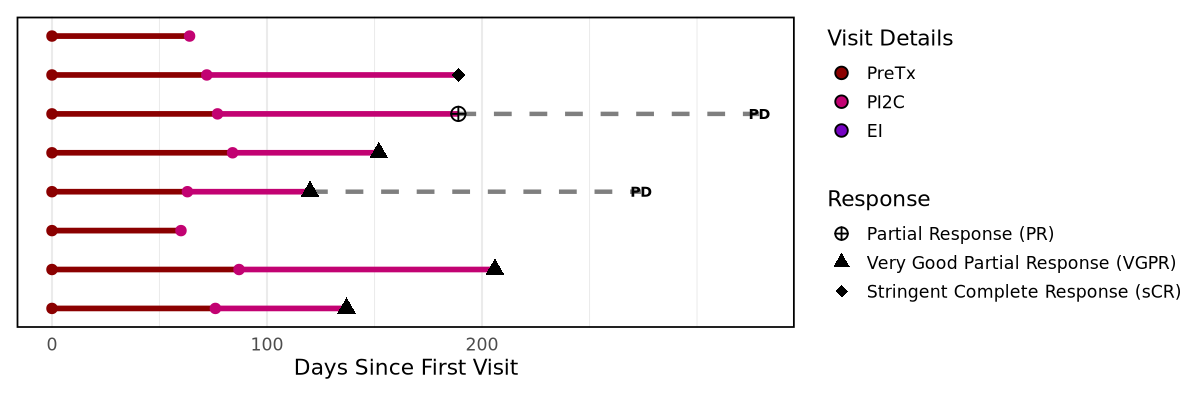

In [7]:
# ── Progressive-disease annotations (VRd patients only) ──
pd_annotations <- tibble(
  Subject             = c("FH1022", "FH1024"),
  daysSinceFirstVisit = c(329, 274),
  PD_label            = "PD"
) %>%
  left_join(
    meta_long %>% select(Subject, SubjectPosition) %>% distinct(),
    by = "Subject"
  )

pd_lines <- meta_long %>%
  filter(Subject %in% pd_annotations$Subject) %>%
  group_by(Subject) %>%
  arrange(daysSinceFirstVisit) %>%
  slice_tail(n = 1) %>%
  left_join(pd_annotations, by = "Subject") %>%
  select(
    Subject,
    x     = daysSinceFirstVisit.x,
    y     = SubjectPosition.x,
    xend  = daysSinceFirstVisit.y,
    yend  = SubjectPosition.x
  )

# ── Segment data (lines between consecutive visits) ──
segment_df <- meta_long %>%
  arrange(Subject, daysSinceFirstVisit) %>%
  group_by(Subject) %>%
  mutate(xend = lead(daysSinceFirstVisit),
         yend = lead(SubjectPosition)) %>%
  filter(!is.na(xend)) %>%
  ungroup()

# ── Build swimmer plot ──
prt <- ggplot() +
  geom_segment(
    data = segment_df,
    aes(x = daysSinceFirstVisit, xend = xend,
        y = SubjectPosition, yend = yend, color = visitDetails),
    linewidth = 1.6
  ) +
  geom_segment(
    data = pd_lines,
    aes(x = x, y = y, xend = xend, yend = yend),
    color = "grey50", linetype = "dashed", linewidth = 1.25
  ) +
  geom_point(
    data = meta_long,
    aes(x = daysSinceFirstVisit, y = SubjectPosition,
        shape = point_shape, fill = fill_color, color = point_color),
    size = 3.5, stroke = 0.8
  ) +
  geom_text(
    data = pd_annotations,
    aes(x = daysSinceFirstVisit, y = SubjectPosition, label = PD_label),
    color = "black", fontface = "bold", size = 3, vjust = 0.5
  ) +
  scale_y_discrete(expand = expansion(add = 0.5)) +
  scale_x_continuous(
    name   = "Days Since First Visit",
    breaks = seq(0, max(meta_long$daysSinceFirstVisit, na.rm = TRUE) + 25, by = 100)
  ) +
  scale_fill_manual(values = tp_color_map, labels = shorthand,
                    name = "Visit Details", drop = FALSE) +
  scale_color_manual(values = c("black" = "black", tp_color_map), guide = "none") +
  scale_shape_manual(values = response_shapes_full, name = "Response",
                     breaks = names(response_shapes)) +
  labs(y = NULL, title = NULL) +
  guides(
    fill  = guide_legend(title = "Visit Details", ncol = 1,
                         override.aes = list(shape = 21, size = 3, color = "black")),
    shape = guide_legend(title = "Response", ncol = 1,
                         override.aes = list(fill = "white", size = 3))
  ) +
  theme_ndmm() +
  theme(
    axis.ticks.y  = element_blank(),
    plot.margin   = margin(10, 30, 10, 10)
  )

prt_nosubj <- prt +
  theme(axis.text.y = element_blank(), axis.ticks.y = element_blank())

options(repr.plot.width = 10, repr.plot.height = 3.3)
print(prt_nosubj)

## Risk Factor Side Panels (RISS Stage & IMWG HRMM)

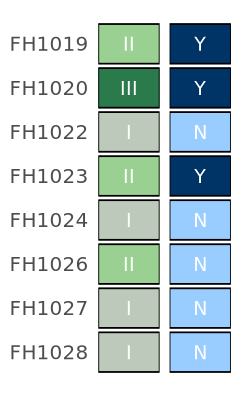

In [8]:
# ── IMWG HRMM lookup (disregarding tp53 mutation criteria) ──
hrmm_lookup <- tibble(
  Subject   = c("FH1019", "FH1020", "FH1022", "FH1023",
                "FH1024", "FH1026", "FH1027", "FH1028"),
  IMWG.HRMM = c("Yes", "Yes", "No", "Yes",
                 "No", "No", "No", "No")
)

# ── Build meta_risk from main CSV (RISS) + IMWG lookup ──
meta_risk <- read.csv("../../data/figure-inputs/metadata/sup_table1.csv", check.names = FALSE) %>%
  filter(Subject %in% g1) %>%
  select(Subject, RISS.stage) %>%
  distinct() %>%
  left_join(hrmm_lookup, by = "Subject") %>%
  mutate(
    Subject = factor(Subject, levels = g1_order),
    SubjectPosition = Subject,
    x = 1
  )

# ── Shared theme for side panels ──
theme_side <- theme_ndmm() +
  theme(
    panel.grid        = element_blank(),
    panel.border      = element_blank(),
    legend.position   = "none",
    plot.title        = element_text(hjust = 0.5, size = 7),
    plot.margin       = margin(5, 0, 5, 0)
  )

# ── RISS stage ──
plot_riss <- ggplot(meta_risk, aes(x = x, y = Subject)) +
  geom_tile(aes(fill = RISS.stage), color = "black",
            width = 1, height = 0.9, linewidth = 0.5) +
  geom_text(aes(label = RISS.stage), color = "white", size = 4) +
  scale_fill_manual(values = riss_colors) +
  scale_x_continuous(expand = c(0, 0), breaks = NULL) +
  scale_y_discrete(position = "left") +
  labs(x = NULL, y = NULL, title = NULL) +
  theme_side +
  theme(axis.text.y  = element_text(size = 12, margin = margin(r = 2)),
        plot.margin  = margin(5, 3, 5, 5))

# ── IMWG HRMM ──
plot_hrmm <- ggplot(meta_risk, aes(x = x, y = Subject)) +
  geom_tile(aes(fill = IMWG.HRMM), color = "black",
            width = 1, height = 0.9, linewidth = 0.5) +
  geom_text(aes(label = ifelse(IMWG.HRMM == "Yes", "Y", "N")),
            color = "white", size = 4) +
  scale_fill_manual(values = hrmm_colors,
                    labels = c("Yes" = "Y", "No" = "N"), name = "IMWG HRMM") +
  scale_x_continuous(expand = c(0, 0), breaks = NULL) +
  scale_y_discrete(position = "right") +
  labs(x = NULL, y = NULL, title = NULL) +
  theme_side +
  theme(axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        plot.margin  = margin(5, 0, 5, 3))

combined_risk <- (plot_riss | plot_hrmm) +
  plot_layout(widths = c(1, 1), guides = "collect")

options(repr.plot.width = 2, repr.plot.height = 3.3)
print(combined_risk)

## Assemble & Save Final Figure

Saved PDF: ../outputs/supplementary-3/sup_3b.pdf



Saved SVG: ../outputs/supplementary-3/sup_3b.svg



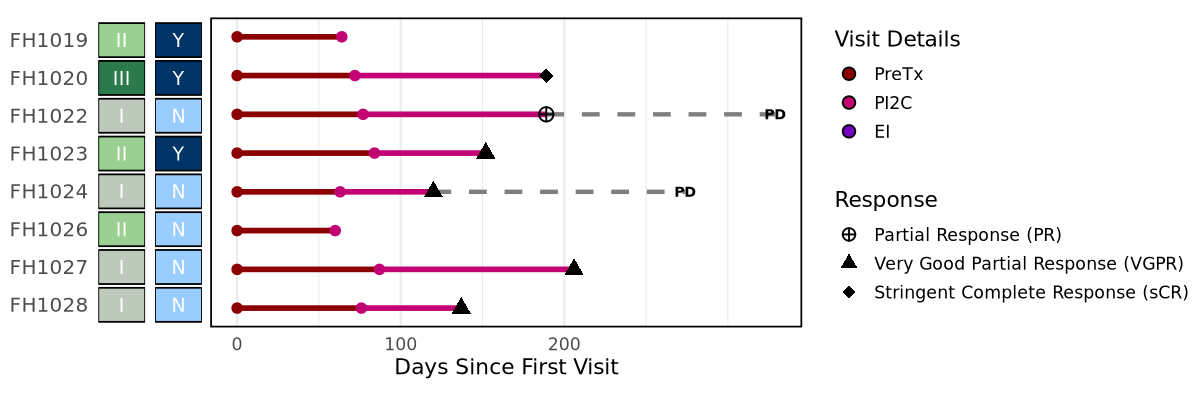

In [9]:
p1 <- prt_nosubj + theme(plot.margin = margin(0, 20, 0, 5))
p2 <- wrap_plots(combined_risk) + theme(plot.margin = margin(0, 0, 0, 0))

sup3b <- (p2 | p1) +
  plot_layout(widths = c(1.4, 8)) +
  plot_annotation(
    theme = theme(plot.title = element_text(hjust = 0.5, size = 14, face = "bold"))
  )

options(repr.plot.width = 10, repr.plot.height = 3.3)
print(sup3b)
save_plot("sup_3b", plot = sup3b, width = 10, height = 3.3)